# Frequency Sweep — Same Path, Filter In/Out (tprocv2)

Characterises the VLF-7200+ filter using a single RF path. Both sweeps use
the **same generator and readout channel**, so the ratio cancels out all cable,
connector, and balun effects and gives a clean filter transfer function.

**Workflow:**
1. Insert the filter. Run the *"Sweep WITH filter"* cell.
2. Remove the filter and reconnect the cable. Run the *"Sweep WITHOUT filter"* cell.
3. Run the *"Plot results"* cell.

---

## Channel selection

| Option | Generator | Readout | Readout type | Notes |
|---|---|---|---|---|
| A | 0 (`axis_signal_gen_v6`) | 0 (`axis_dyn_readout_v1`) | Dynamic | Standard gen, ADC port 4 |
| B | 3 (`axis_sg_mux8_v1`) | 2 (`axis_pfb_readout_v3`) | Static (PYNQ) | Mux gen, ADC port 6 |

Set `USE_OPTION` below. Option B gave better-balanced results in testing.

In [1]:
from qick import *
from qick.asm_v2 import AveragerProgramV2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from tqdm import tqdm
%matplotlib inline

In [2]:
soc = QickSoc(bitfile="../../qick/firmware/projects/2024-09-03_216_tprovc2r21_demo/qick_216.bit")
soccfg = soc
print(soccfg)

QICK running on ZCU216, software version 0.2.396

Firmware configuration (built Tue Sep  3 12:55:04 2024):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	5 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 16384 complex samples (1.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 0 is 0_231 on JHC3, or QICK box DAC port 12
	2:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)
		32-bit DDS, range=1720.320 MHz
		DAC tile 3, blk 1 is 1_231 on JHC4, or QICK box DAC port 13
	3:	axis_sg_mux8_v1 - fs=9830.400 Msps, fabric=614.400 MHz
		32-bit DDS, range=

In [3]:
# ── Choose hardware path ───────────────────────────────────────────────────────
USE_OPTION = "B"   # "A" = gen 0 / RO 0   |   "B" = gen 3 / RO 2

if USE_OPTION == "A":
    GEN_CH   = 0   # axis_signal_gen_v6
    RO_CH    = 0   # axis_dyn_readout_v1  (dynamic)
    RO_STATIC = False
elif USE_OPTION == "B":
    GEN_CH   = 3   # axis_sg_mux8_v1
    RO_CH    = 2   # axis_pfb_readout_v3  (static / PYNQ-configured)
    RO_STATIC = True
else:
    raise ValueError("USE_OPTION must be 'A' or 'B'")

print(f"Using Gen {GEN_CH} → RO {RO_CH}  "
      f"({'static' if RO_STATIC else 'dynamic'} readout)")
print(f"Gen type:  {soccfg['gens'][GEN_CH]['type']}")
print(f"RO  type:  {soccfg['readouts'][RO_CH]['ro_type']}")

Using Gen 3 → RO 2  (static readout)
Gen type:  axis_sg_mux8_v1
RO  type:  axis_pfb_readout_v3


## Program definitions

Two classes are defined to handle both static and dynamic readout channels.
The correct one is selected automatically based on `RO_STATIC`.

In [4]:
# ── Option A: axis_signal_gen_v6 + dynamic readout ────────────────────────────
class SweepProgramDynamic(AveragerProgramV2):
    """Standard gen_v6 with dynamic readout (ch 0 or 1).
    DDC frequency sent via tProc at runtime."""
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg["res_ch"], nqz=cfg["nqz"])
        self.declare_readout(ch=cfg["ro_chs"][0], length=cfg["readout_length"])
        self.add_readoutconfig(
            ch=cfg["ro_chs"][0], 
            name="ro_cfg",
            freq=53.720 # cfg["pulse_freq"], 
            # gen_ch=cfg["res_ch"]
        )
        self.add_pulse(
            ch=cfg["res_ch"], name="pulse", style="const",
            freq=cfg["pulse_freq"], phase=cfg["res_phase"],
            gain=cfg["pulse_gain"], length=cfg["length"]
        )
        self.delay_auto(0.5)

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg["ro_chs"][0], name="ro_cfg", t=0)
        self.pulse(ch=cfg["res_ch"], name="pulse", t=0)
        self.trigger(ros=[cfg["ro_chs"][0]], t=cfg["adc_trig_offset"])
        self.delay_auto(cfg["relax_delay"])


# ── Option B: axis_sg_mux8_v1 + static readout ────────────────────────────────
class SweepProgramStatic(AveragerProgramV2):
    """Mux8 gen with static/PYNQ readout (ch 2-6).
    DDC frequency set directly in declare_readout.
    No send_readoutconfig needed."""
    def _initialize(self, cfg):
        self.declare_gen(
            ch=cfg["res_ch"], nqz=cfg["nqz"],
            mux_freqs=[cfg["pulse_freq"]],
            mux_gains=[cfg["pulse_gain"]],
        )
        # freq and gen_ch go here for static readouts
        self.declare_readout(
            ch=cfg["ro_chs"][0], length=cfg["readout_length"],
            freq=cfg["pulse_freq"], gen_ch=cfg["res_ch"]
        )
        # mask=[0] plays only the first tone from mux_freqs
        self.add_pulse(
            ch=cfg["res_ch"], name="pulse",
            style="const", mask=[0], length=cfg["length"]
        )
        self.delay_auto(0.5)

    def _body(self, cfg):
        # No send_readoutconfig for static readouts
        self.pulse(ch=cfg["res_ch"], name="pulse", t=0)
        self.trigger(ros=[cfg["ro_chs"][0]], t=cfg["adc_trig_offset"])
        self.delay_auto(cfg["relax_delay"])


# Select the right class based on readout type
SweepProgram = SweepProgramStatic if RO_STATIC else SweepProgramDynamic
print(f"Using program class: {SweepProgram.__name__}")

Using program class: SweepProgramStatic


In [5]:
# ── Sweep parameters ───────────────────────────────────────────────────────────
freqs_mhz = np.linspace(4000, 9000, 100)   # 50 MHz steps

base_config = {
    "res_ch":    GEN_CH,
    "ro_chs":    [RO_CH],
    "reps":      200,
    "relax_delay": 1.0,           # µs
    "res_phase": 0,
    "pulse_gain": 30000 / 32767,  # normalized gain
    "adc_trig_offset": 0.0,       # µs
    "rounds":    1,
    "nqz":       2,
    "length":    soccfg.cycles2us(100, gen_ch=GEN_CH),
    "readout_length": soccfg.cycles2us(200, ro_ch=RO_CH),
}

print(f"Sweeping {len(freqs_mhz)} points: {freqs_mhz[0]:.0f}–{freqs_mhz[-1]:.0f} MHz")
print(f"Gen {GEN_CH} → RO {RO_CH}  |  "
      f"gain={base_config['pulse_gain']:.3f}  |  reps={base_config['reps']}")
hardware_time_s = len(freqs_mhz) * 2 * base_config['reps'] * base_config['relax_delay'] * 1e-6
print(f"Hardware-only minimum: ~{hardware_time_s:.2f} s")
print(f"Realistic estimate with Python overhead: ~{len(freqs_mhz) * 2 * 0.5:.0f}–{len(freqs_mhz) * 2 * 2:.0f} s")
print(f"  ({len(freqs_mhz) * 2} program compile+acquire calls, roughly 0.5–2 s each)")

Sweeping 100 points: 4000–9000 MHz
Gen 3 → RO 2  |  gain=0.916  |  reps=200
Hardware-only minimum: ~0.04 s
Realistic estimate with Python overhead: ~100–400 s
  (200 program compile+acquire calls, roughly 0.5–2 s each)


In [6]:
# ── Helper function ────────────────────────────────────────────────────────────
def run_sweep(label):
    """Run a full frequency sweep and return (actual_freqs, magnitudes)."""
    mags = []
    actual_freqs = []
    for freq in tqdm(freqs_mhz, desc=f"Sweeping ({label})"):
        f = soccfg.adcfreq(freq, GEN_CH, RO_CH)
        actual_freqs.append(f)
        cfg = {**base_config, "pulse_freq": f}
        prog = SweepProgram(soccfg, reps=cfg["reps"],
                            final_delay=cfg["relax_delay"], cfg=cfg)
        result = prog.acquire(soc, rounds=cfg["rounds"], progress=False)
        I, Q = result[0][0][0], result[0][0][1]
        mags.append(np.sqrt(I**2 + Q**2))
    return np.array(actual_freqs), np.array(mags)

---
## Step 1 — Sweep WITH filter

**Make sure the VLF-7200+ LPF is connected in the signal path, then run this cell.**

Sweeping (with filter): 100%|██████████| 100/100 [00:05<00:00, 17.08it/s]


Done. Peak magnitude: 38.6 a.u.
Saved to mags_with_filter.npy


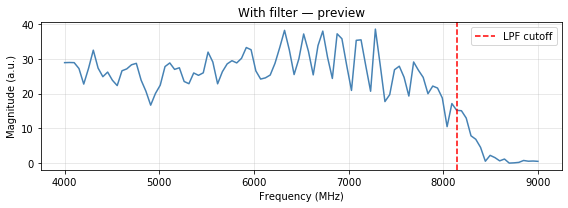

In [7]:
freqs_with, mags_with = run_sweep("with filter")

# Save immediately so data is safe if anything crashes later
np.save("mags_with_filter.npy", mags_with)
np.save("actual_freqs.npy",     freqs_with)
print(f"Done. Peak magnitude: {np.max(mags_with):.1f} a.u.")
print("Saved to mags_with_filter.npy")

# Quick preview
plt.figure(figsize=(8, 3))
plt.plot(freqs_with, mags_with, color='steelblue')
plt.axvline(x=8150, color='red', linestyle='--', label='LPF cutoff')
plt.xlabel("Frequency (MHz)"); plt.ylabel("Magnitude (a.u.)")
plt.title("With filter — preview"); plt.legend(); plt.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()

---
## Step 2 — Remove the filter

1. **Remove the VLF-7200+ from the signal path**
2. **Reconnect the cable directly** (same connectors, same torque)
3. Run the cell below

> Tip: finger-tight plus a quarter turn both times for consistent connector seating.

Sweeping (no filter): 100%|██████████| 100/100 [00:05<00:00, 17.01it/s]


Done. Peak magnitude: 107.9 a.u.
Saved to mags_no_filter.npy


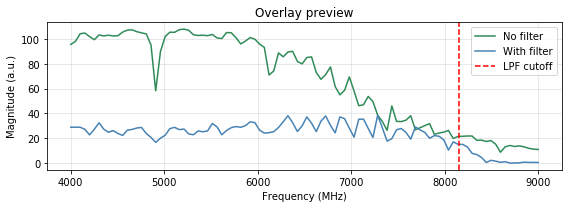

In [8]:
freqs_without, mags_without = run_sweep("no filter")

np.save("mags_no_filter.npy",  mags_without)
print(f"Done. Peak magnitude: {np.max(mags_without):.1f} a.u.")
print("Saved to mags_no_filter.npy")

# Quick preview overlay
plt.figure(figsize=(8, 3))
plt.plot(freqs_without, mags_without, color='seagreen',  label='No filter')
plt.plot(freqs_with,    mags_with,    color='steelblue', label='With filter')
plt.axvline(x=8150, color='red', linestyle='--', label='LPF cutoff')
plt.xlabel("Frequency (MHz)"); plt.ylabel("Magnitude (a.u.)")
plt.title("Overlay preview"); plt.legend(); plt.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()

---
## Step 3 — Plot results

In [9]:
# ── Load saved data (safe to re-run even after kernel restart) ────────────────
freqs_with    = np.load("actual_freqs.npy")
mags_with     = np.load("mags_with_filter.npy")
mags_without  = np.load("mags_no_filter.npy")

# ── Filter transfer function ───────────────────────────────────────────────────
# Same path → hardware response cancels perfectly in the ratio
safe_ref = np.where(mags_without > 0.1, mags_without, np.nan)
filter_tf = mags_with / safe_ref

# Normalize to passband (5000-6500 MHz) to account for any small
# connector seating difference between the two runs
passband_mask = freqs_with < 6500
passband_mean = np.nanmean(filter_tf[passband_mask])
filter_tf_norm = filter_tf / passband_mean
print(f"Passband mean ratio before normalization: {passband_mean:.3f}")
print(f"(Should be close to 1.0 if connectors seated consistently)")

# Optional smoothing to reduce standing wave ripple
filter_tf_smooth = savgol_filter(
    np.nan_to_num(filter_tf_norm, nan=0.0),
    window_length=7, polyorder=2
)

Passband mean ratio before normalization: 0.279
(Should be close to 1.0 if connectors seated consistently)


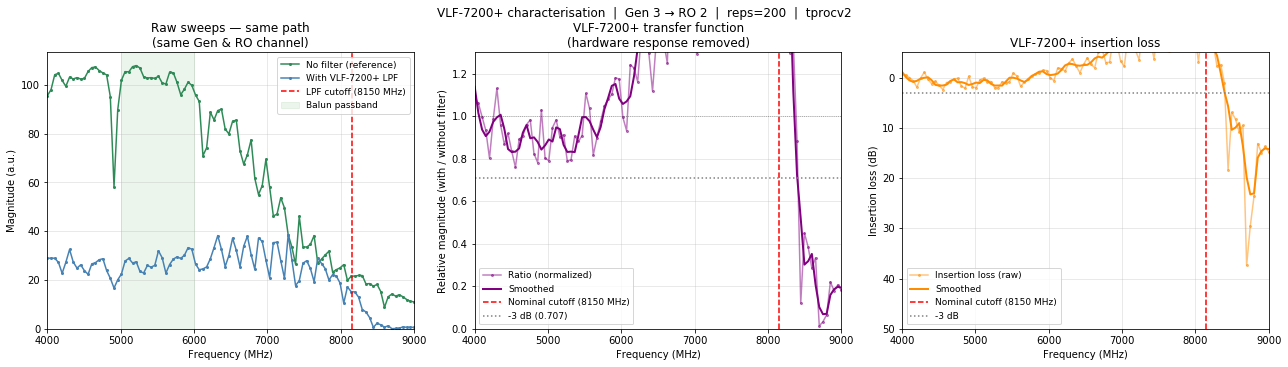

Saved to vlf7200_characterisation.png


In [10]:
# ── Main plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Raw sweeps overlay ────────────────────────────────────────────────
ax = axes[0]
ax.plot(freqs_without, mags_without, color='seagreen',  lw=1.5, marker='.', ms=4,
        label='No filter (reference)')
ax.plot(freqs_with,    mags_with,    color='steelblue', lw=1.5, marker='.', ms=4,
        label='With VLF-7200+ LPF')
ax.axvline(x=8150,    color='red',    ls='--', lw=1.5, label='LPF cutoff (8150 MHz)')
ax.axvspan(5000, 6000, alpha=0.08, color='green', label='Balun passband')
ax.set_xlabel("Frequency (MHz)"); ax.set_ylabel("Magnitude (a.u.)")
ax.set_title("Raw sweeps — same path\n(same Gen & RO channel)")
ax.set_xlim(freqs_mhz[0], freqs_mhz[-1]); ax.set_ylim(bottom=0)
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# ── Plot 2: Normalized transfer function (raw ratio) ─────────────────────────
ax = axes[1]
ax.plot(freqs_with, filter_tf_norm, color='purple', lw=1.5, marker='.', ms=4,
        label='Ratio (normalized)', alpha=0.5)
ax.plot(freqs_with, filter_tf_smooth, color='purple', lw=2.0,
        label='Smoothed')
ax.axvline(x=8150,         color='red',  ls='--', lw=1.5, label='Nominal cutoff (8150 MHz)')
ax.axhline(y=1/np.sqrt(2), color='gray', ls=':',  lw=1.5, label='-3 dB (0.707)')
ax.axhline(y=1.0,          color='black',ls=':',  lw=0.8, alpha=0.4)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Relative magnitude (with / without filter)")
ax.set_title("VLF-7200+ transfer function\n(hardware response removed)")
ax.set_xlim(freqs_mhz[0], freqs_mhz[-1]); ax.set_ylim(0, 1.3)
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

# ── Plot 3: Insertion loss in dB ──────────────────────────────────────────────
ax = axes[2]
with np.errstate(divide='ignore', invalid='ignore'):
    loss_db        = -20 * np.log10(np.abs(filter_tf_norm))
    loss_db_smooth = -20 * np.log10(np.abs(filter_tf_smooth))
ax.plot(freqs_with, loss_db,        color='darkorange', lw=1.5, marker='.', ms=4,
        alpha=0.5, label='Insertion loss (raw)')
ax.plot(freqs_with, loss_db_smooth, color='darkorange', lw=2.0,
        label='Smoothed')
ax.axvline(x=8150, color='red',  ls='--', lw=1.5, label='Nominal cutoff (8150 MHz)')
ax.axhline(y=3.0,  color='gray', ls=':',  lw=1.5, label='-3 dB')
ax.set_xlabel("Frequency (MHz)"); ax.set_ylabel("Insertion loss (dB)")
ax.set_title("VLF-7200+ insertion loss")
ax.set_xlim(freqs_mhz[0], freqs_mhz[-1])
ax.set_ylim(-5, 50)   # clip extreme values from noise
ax.invert_yaxis()     # convention: loss is positive downward
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

plt.suptitle(
    f"VLF-7200+ characterisation  |  Gen {GEN_CH} → RO {RO_CH}  |  "
    f"reps={base_config['reps']}  |  tprocv2",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("vlf7200_characterisation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to vlf7200_characterisation.png")

In [11]:
# ── Find -3 dB crossing frequency ─────────────────────────────────────────────
below_3db = filter_tf_smooth < 1/np.sqrt(2)
if np.any(below_3db):
    idx_3db = np.argmax(below_3db)   # first index where response drops below -3 dB
    f_3db = freqs_with[idx_3db]
    print(f"-3 dB crossing: {f_3db:.1f} MHz  (nominal spec: 8150 MHz)")
    print(f"Deviation from spec: {f_3db - 8150:+.1f} MHz")
else:
    print("Response never drops below -3 dB in this sweep range.")

# Passband insertion loss
passband_loss_db = -20 * np.log10(passband_mean)
print(f"Passband insertion loss: {passband_loss_db:.2f} dB  (ideally < 2.5 dB)")

-3 dB crossing: 8444.4 MHz  (nominal spec: 8150 MHz)
Deviation from spec: +294.4 MHz
Passband insertion loss: 11.10 dB  (ideally < 2.5 dB)


---
## Diagnostic: decimated trace + DDC beat frequency

Run this if you see oscillating I/Q in the sanity check — it identifies
and corrects a DDC frequency mismatch.

  0%|          | 0/1 [00:00<?, ?it/s]

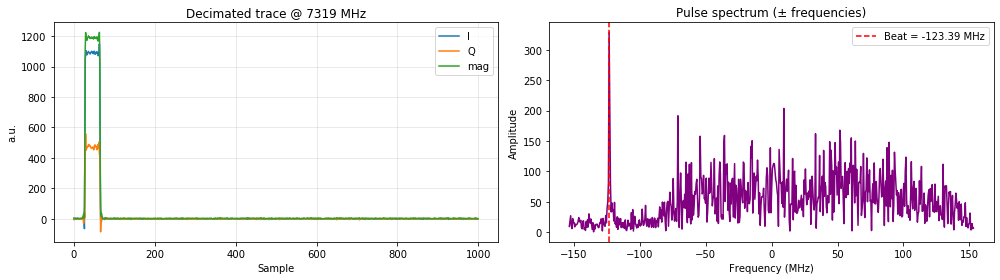

Beat frequency  : -123.392 MHz
Current DDC freq: 7319.000 MHz

⚠  Beat > 1 MHz — DDC mismatch detected.
   Manually set DDC alias to 177.192 MHz
   i.e. use add_readoutconfig(freq=177.192) without gen_ch


In [12]:
DIAG_FREQ = 7319   # MHz

diag_cfg = {
    **base_config,
    "pulse_freq":     soccfg.adcfreq(DIAG_FREQ, GEN_CH, RO_CH),
    "reps":           1,
    "length":         soccfg.cycles2us(600, gen_ch=GEN_CH),
    "readout_length": soccfg.cycles2us(1000, ro_ch=RO_CH),
}

prog_diag = SweepProgram(soccfg, reps=diag_cfg["reps"],
                         final_delay=diag_cfg["relax_delay"], cfg=diag_cfg)
iq_dec = prog_diag.acquire_decimated(soc)

I_trace = iq_dec[0][:, 0]
Q_trace = iq_dec[0][:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(I_trace, label='I'); axes[0].plot(Q_trace, label='Q')
axes[0].plot(np.abs(I_trace + 1j*Q_trace), label='mag')
axes[0].set_title(f"Decimated trace @ {DIAG_FREQ} MHz")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("a.u."); axes[0].legend()
axes[0].grid(True, alpha=0.35)

# FFT — full two-sided spectrum to catch negative-frequency beats
pulse_start, pulse_end = 100, 700
pulse = I_trace[pulse_start:pulse_end] + 1j * Q_trace[pulse_start:pulse_end]
fs_dec = soccfg['readouts'][RO_CH]['f_fabric']
freqs_fft = np.fft.fftshift(np.fft.fftfreq(len(pulse), d=1/fs_dec))
spectrum  = np.abs(np.fft.fftshift(np.fft.fft(pulse)))
dc_bin    = len(freqs_fft) // 2
spec_no_dc = spectrum.copy(); spec_no_dc[dc_bin-3:dc_bin+3] = 0
beat_freq = freqs_fft[np.argmax(spec_no_dc)]

axes[1].plot(freqs_fft, spectrum, color='purple')
axes[1].axvline(x=beat_freq, color='red', ls='--',
                label=f'Beat = {beat_freq:.2f} MHz')
axes[1].set_title("Pulse spectrum (± frequencies)")
axes[1].set_xlabel("Frequency (MHz)"); axes[1].set_ylabel("Amplitude")
axes[1].legend(); plt.tight_layout(); plt.show()

print(f"Beat frequency  : {beat_freq:.3f} MHz")
print(f"Current DDC freq: {diag_cfg['pulse_freq']:.3f} MHz")
if abs(beat_freq) > 1:
    print(f"\n⚠  Beat > 1 MHz — DDC mismatch detected.")
    print(f"   Manually set DDC alias to {53.8 - beat_freq:.3f} MHz")
    print(f"   i.e. use add_readoutconfig(freq={53.8 - beat_freq:.3f}) without gen_ch")
else:
    print("✓  Beat < 1 MHz — DDC looks well matched.")